Parameters: 111,146
Epoch  1 | Loss: 0.4522 | Accuracy: 95.15%
Epoch  2 | Loss: 0.2083 | Accuracy: 96.52%
Epoch  3 | Loss: 0.1631 | Accuracy: 97.08%
Epoch  4 | Loss: 0.1422 | Accuracy: 97.27%
Epoch  5 | Loss: 0.1303 | Accuracy: 97.42%
Epoch  6 | Loss: 0.1184 | Accuracy: 97.43%
Epoch  7 | Loss: 0.1077 | Accuracy: 97.81%
Epoch  8 | Loss: 0.1001 | Accuracy: 97.76%
Epoch  9 | Loss: 0.0958 | Accuracy: 97.52%
Epoch 10 | Loss: 0.0913 | Accuracy: 97.90%


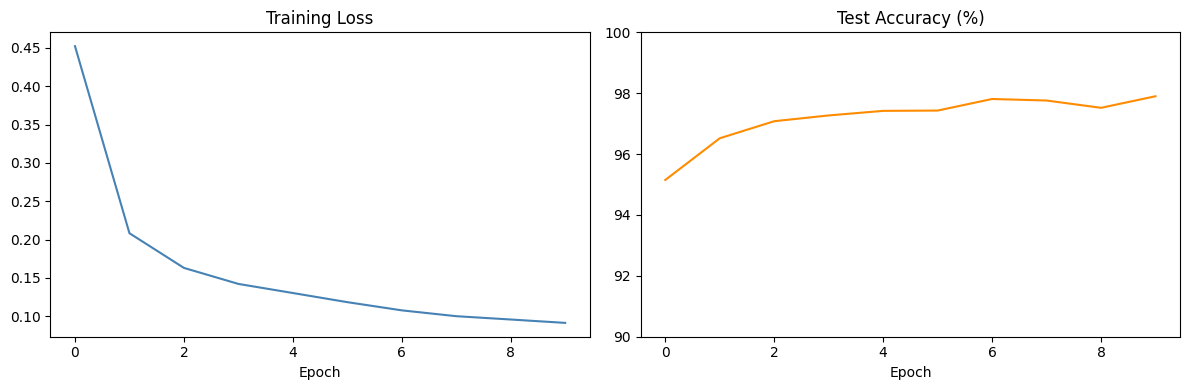

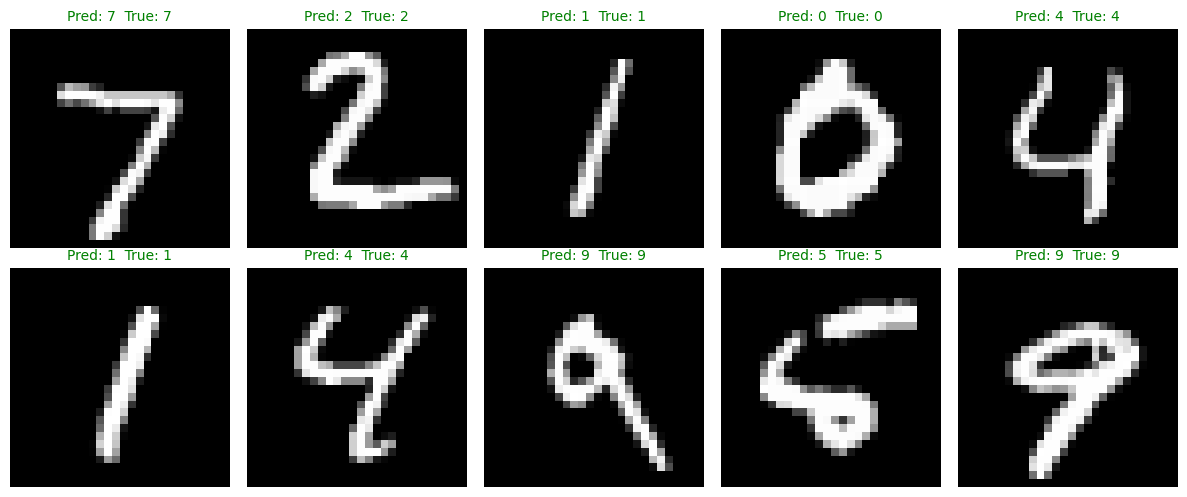

Model saved!


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ── 1. Load & Preprocess Data ──────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

# ── 2. Define the Neural Network ───────────────────────────────────────────
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        return self.network(x)

model = DigitClassifier()
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── 3. Training Setup ──────────────────────────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ── 4. Train ───────────────────────────────────────────────────────────────
def train(epochs=10):
    train_losses, test_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Evaluate on test set
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                correct += (predicted == labels).sum().item()
                total   += labels.size(0)

        acc  = 100 * correct / total
        loss = running_loss / len(train_loader)
        train_losses.append(loss)
        test_accuracies.append(acc)
        print(f"Epoch {epoch+1:2d} | Loss: {loss:.4f} | Accuracy: {acc:.2f}%")

    return train_losses, test_accuracies

losses, accuracies = train(epochs=10)

# ── 5. Plot Results ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(losses, color='steelblue')
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")

ax2.plot(accuracies, color='darkorange')
ax2.set_title("Test Accuracy (%)")
ax2.set_xlabel("Epoch")
ax2.set_ylim(90, 100)

plt.tight_layout()
plt.savefig("training_results.png", dpi=150)
plt.show()

# ── 6. Visualize Predictions ───────────────────────────────────────────────
model.eval()
images, labels = next(iter(test_loader))
images = images[:10]

with torch.no_grad():
    outputs   = model(images.to(device))
    predicted = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    color = 'green' if predicted[i] == labels[i] else 'red'
    ax.set_title(f"Pred: {predicted[i]}  True: {labels[i]}", color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()

# ── 7. Save the Model ──────────────────────────────────────────────────────
torch.save(model.state_dict(), "mnist_model.pth")
print("Model saved!")